In [2]:
!pip install statsmodels scipy seaborn duckdb


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Imports loaded.")

Imports loaded.


In [4]:
import os
print(os.getcwd())

C:\Users\Harshil\OneDrive - Wittenborg University of Applied Sciences (1)\MBA_DA\Code basics\Bever style Project\Hoogland Project


In [11]:
import subprocess
result = subprocess.run(
    ['where', '/R', r'C:\Users', 'hoogland.duckdb'],
    capture_output=True, text=True, timeout=60
)
print(result.stdout or "Not found via where. Try the Properties method instead.")

C:\Users\Harshil\OneDrive - Wittenborg University of Applied Sciences (1)\MBA_DA\Code basics\Bever style Project\Hoogland Project\dbt_hoogland\hoogland.duckdb



In [12]:
DB_PATH = Path("dbt_hoogland/hoogland.duckdb")

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"✅ Connected to: {DB_PATH.resolve()}")

def q(sql):
    return con.execute(sql).df()

✅ Connected to: C:\Users\Harshil\OneDrive - Wittenborg University of Applied Sciences (1)\MBA_DA\Code basics\Bever style Project\Hoogland Project\dbt_hoogland\hoogland.duckdb


In [13]:
import os
import duckdb
from pathlib import Path

# ── DuckDB connection ──
DB_PATH = Path("dbt_hoogland/hoogland.duckdb")

# 1. Try connecting locally first
if DB_PATH.exists():
    con = duckdb.connect(str(DB_PATH), read_only=True)
    print(f"✅ Connected locally to: {DB_PATH.resolve()}")
else:
    con = None

# 2. If local fails, try cloud (MotherDuck)
MD_TOKEN = os.environ.get("MOTHERDUCK_TOKEN")
if con is None and MD_TOKEN:
    con = duckdb.connect(f"md:hoogland?motherduck_token={MD_TOKEN}", read_only=True)
    print("✅ Connected to MotherDuck (cloud)")

# 3. If both failed, raise the error
if con is None:
    raise RuntimeError(
        f"❌ No database found at {DB_PATH.resolve()}! \n"
        "Check your file path or ensure your MOTHERDUCK_TOKEN is set."
    )

# Shortcut: q("SELECT ...") returns a pandas DataFrame
def q(sql):
    return con.execute(sql).df()

✅ Connected locally to: C:\Users\Harshil\OneDrive - Wittenborg University of Applied Sciences (1)\MBA_DA\Code basics\Bever style Project\Hoogland Project\dbt_hoogland\hoogland.duckdb


In [14]:
# ── List all tables ──
tables = q("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
    ORDER BY table_schema, table_name
""")
print("📦 Tables in the warehouse:")
print(tables.to_string(index=False))

📦 Tables in the warehouse:
table_schema                table_name
        main      int_customer_metrics
        main    int_inventory_enriched
        main        int_sales_enriched
        main   int_sales_with_campaign
        main   int_weather_store_daily
        main         mart_customer_clv
        main     mart_inventory_health
        main  mart_promo_effectiveness
        main    mart_store_performance
        main       mart_weather_demand
        main  stg_campaign_sku_mapping
        main             stg_dim_brand
        main          stg_dim_campaign
        main          stg_dim_customer
        main              stg_dim_date
        main           stg_dim_product
        main             stg_dim_store
        main     stg_ext_weather_daily
        main stg_fact_inventory_weekly
        main          stg_fact_returns
        main            stg_fact_sales
        main    stg_fact_supply_orders
        main    stg_fact_traffic_daily


In [15]:
# ── List columns for each mart ──
# This tells you the exact column names you'll use in queries.
# If a mart name below doesn't match your warehouse, update the name.

MART_NAMES = [
    "mart_store_performance",
    "mart_promo_effectiveness",
    "mart_customer_clv",
    "mart_inventory_health",
    "mart_weather_demand",
]

for m in MART_NAMES:
    try:
        cols = q(f"""
            SELECT column_name, data_type
            FROM information_schema.columns
            WHERE table_name = '{m}'
            ORDER BY ordinal_position
        """)
        print(f"\n{'─'*50}")
        print(f"📋 {m}")
        print(f"{'─'*50}")
        print(cols.to_string(index=False))
    except Exception as e:
        print(f"\n⚠️ {m} not found — check spelling: {e}")


──────────────────────────────────────────────────
📋 mart_store_performance
──────────────────────────────────────────────────
        column_name data_type
           store_id   VARCHAR
         store_name   VARCHAR
               city   VARCHAR
             region   VARCHAR
          archetype   VARCHAR
      store_channel   VARCHAR
                sqm    BIGINT
          is_outlet   BOOLEAN
               date      DATE
  gross_revenue_eur    DOUBLE
    net_revenue_eur    DOUBLE
 total_discount_eur    DOUBLE
         units_sold   HUGEINT
       transactions    BIGINT
     avg_basket_eur    DOUBLE
   total_margin_eur    DOUBLE
         margin_pct    DOUBLE
revenue_per_sqm_eur    DOUBLE

──────────────────────────────────────────────────
📋 mart_promo_effectiveness
──────────────────────────────────────────────────
        column_name data_type
        campaign_id   VARCHAR
      campaign_name   VARCHAR
      campaign_type   VARCHAR
campaign_start_date      DATE
  campaign_end_date   

In [16]:
baseline = q("""
    SELECT
        ROUND(SUM(gross_revenue_eur) / 1e6, 1) AS gross_eur_m,
        ROUND(SUM(net_revenue_eur)   / 1e6, 1) AS net_eur_m,
        ROUND(AVG(margin_pct) * 100,        2) AS margin_pct,
        ROUND(AVG(avg_basket_eur),          2) AS avg_basket,
        COUNT(DISTINCT store_id)               AS stores
    FROM mart_store_performance
""")

print("📊 From the warehouse:")
print(baseline.to_string(index=False))
print()
print("📊 Week 3 baseline:")
print("   gross_eur_m = 393.0 | net_eur_m = 379.0 | margin = 45.35 | basket = 162 | stores = 55")

📊 From the warehouse:
 gross_eur_m  net_eur_m  margin_pct  avg_basket  stores
      393.10     379.30       45.35      162.06      55

📊 Week 3 baseline:
   gross_eur_m = 393.0 | net_eur_m = 379.0 | margin = 45.35 | basket = 162 | stores = 55


In [18]:
# ── H6: Pareto — SKU concentration ──

# Use sales_units from inventory mart (SKU-level data)
sku_rev = q("""
    SELECT
        sku,
        product_name,
        category,
        SUM(sales_units)         AS total_units,
        SUM(inventory_value_eur) AS inventory_cost,
        SUM(est_lost_revenue_eur) AS est_lost_revenue
    FROM mart_inventory_health
    GROUP BY sku, product_name, category
    ORDER BY total_units DESC
""")

# Calculate cumulative share based on units sold
sku_rev["unit_share"]       = sku_rev["total_units"] / sku_rev["total_units"].sum()
sku_rev["cumulative_share"] = sku_rev["unit_share"].cumsum()
sku_rev["sku_rank_pct"]     = [i / len(sku_rev) * 100 for i in range(1, len(sku_rev) + 1)]

# Key Pareto breakpoints
top_20 = sku_rev[sku_rev["sku_rank_pct"] <= 20]
top_20_share = top_20["total_units"].sum() / sku_rev["total_units"].sum() * 100

bottom_50 = sku_rev[sku_rev["sku_rank_pct"] > 50]
bottom_50_share = bottom_50["total_units"].sum() / sku_rev["total_units"].sum() * 100
bottom_50_inventory = bottom_50["inventory_cost"].sum()

print(f"Total SKUs: {len(sku_rev):,}")
print(f"Top 20% of SKUs generate:    {top_20_share:.1f}% of units sold")
print(f"Bottom 50% of SKUs generate: {bottom_50_share:.1f}% of units sold")
print(f"Bottom 50% tied-up inventory: €{bottom_50_inventory:,.0f}")

Total SKUs: 620
Top 20% of SKUs generate:    81.8% of units sold
Bottom 50% of SKUs generate: 4.6% of units sold
Bottom 50% tied-up inventory: €116,409,847


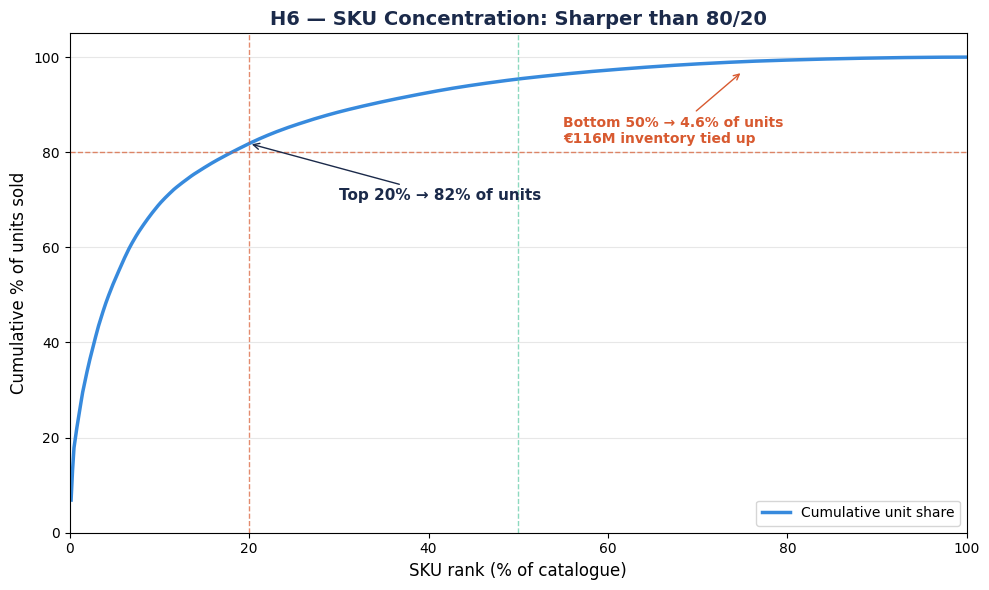

In [19]:
# ── H6: Pareto curve ──
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    sku_rev["sku_rank_pct"],
    sku_rev["cumulative_share"] * 100,
    color="#378ADD", linewidth=2.5, label="Cumulative unit share"
)

# Reference lines
ax.axhline(80, color="#D85A30", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(20, color="#D85A30", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(50, color="#5DCAA5", linestyle="--", linewidth=1, alpha=0.7)

# Annotations
ax.annotate(f"Top 20% → {top_20_share:.0f}% of units",
            xy=(20, top_20_share), xytext=(30, 70),
            fontsize=11, fontweight="bold", color="#1B2A4A",
            arrowprops=dict(arrowstyle="->", color="#1B2A4A"))

ax.annotate(f"Bottom 50% → {bottom_50_share:.1f}% of units\n€{bottom_50_inventory/1e6:.0f}M inventory tied up",
            xy=(75, 97), xytext=(55, 82),
            fontsize=10, color="#D85A30", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#D85A30"))

ax.set_xlabel("SKU rank (% of catalogue)", fontsize=12)
ax.set_ylabel("Cumulative % of units sold", fontsize=12)
ax.set_title("H6 — SKU Concentration: Sharper than 80/20", fontsize=14, fontweight="bold", color="#1B2A4A")
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ── H6: Long-tail breakdown by category ──
bottom_50_skus = sku_rev[sku_rev["sku_rank_pct"] > 50]

tail_by_cat = bottom_50_skus.groupby("category").agg(
    sku_count=("sku", "count"),
    total_units=("total_units", "sum"),
    inventory_tied=("inventory_cost", "sum")
).sort_values("inventory_tied", ascending=False)

tail_by_cat["avg_inventory_per_sku"] = tail_by_cat["inventory_tied"] / tail_by_cat["sku_count"]
tail_by_cat["inventory_tied_m"] = tail_by_cat["inventory_tied"] / 1e6

print("📦 Bottom 50% SKUs — inventory trapped by category:\n")
print(tail_by_cat[["sku_count", "total_units", "inventory_tied_m", "avg_inventory_per_sku"]]
      .rename(columns={
          "sku_count": "SKUs",
          "total_units": "Units sold",
          "inventory_tied_m": "Inventory €M",
          "avg_inventory_per_sku": "Avg €/SKU"
      })
      .to_string())
print(f"\nTotal trapped capital: €{tail_by_cat['inventory_tied'].sum()/1e6:.0f}M")

📦 Bottom 50% SKUs — inventory trapped by category:

                   SKUs  Units sold  Inventory €M  Avg €/SKU
category                                                    
Apparel Technical   118   61,747.00         50.38 426,985.19
Hiking               62   39,151.00         22.70 366,070.38
Ski & Winter         64   29,088.00         21.48 335,693.51
Apparel Lifestyle    21   16,347.00          7.10 337,972.71
Footwear             20   13,313.00          4.97 248,296.47
Climbing             10    7,891.00          4.14 414,483.41
Travel                9    6,342.00          3.40 377,680.36
Camping               5    3,512.00          2.19 437,326.66
Accessories           1      628.00          0.05  50,899.86

Total trapped capital: €116M


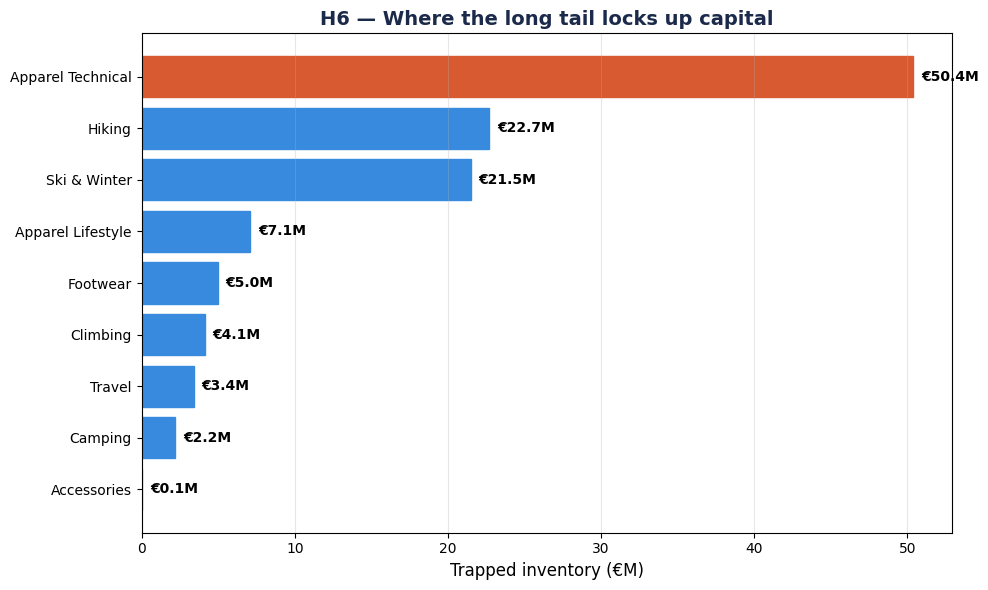

In [21]:
# ── H6: Trapped capital by category chart ──
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    tail_by_cat.sort_values("inventory_tied").index,
    tail_by_cat.sort_values("inventory_tied")["inventory_tied_m"],
    color="#378ADD", edgecolor="white"
)

# Highlight the biggest offender
colors = ["#378ADD"] * len(tail_by_cat)
colors[-1] = "#D85A30"  # top bar = Apparel Technical
for bar, c in zip(bars, colors):
    bar.set_color(c)

ax.set_xlabel("Trapped inventory (€M)", fontsize=12)
ax.set_title("H6 — Where the long tail locks up capital", fontsize=14, fontweight="bold", color="#1B2A4A")
ax.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f"€{width:.1f}M", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### H6 - Finding: SKU Concentration

**Claim tested:** A small percentage of SKUs drives most of the revenue.

**Result:** Confirmed - sharper than classic 80/20.
- Top 20% of SKUs → 82% of units sold
- Bottom 50% (310 SKUs) → just 4.6% of units, yet €116M in tied-up inventory

**Worst offenders:**
- Apparel Technical: 118 SKUs, €50M trapped (43% of total dead stock)
- Hiking: 62 SKUs, €23M trapped
- Ski & Winter: 64 SKUs, €21M trapped

**€ Impact:** A 30% range reduction in the bottom-50 tail releases ~€35M in working capital.

**Recommendation:** Initiate a category-by-category range rationalisation, starting with Apparel Technical. Exit or consolidate SKUs with <500 annual units and >€300K inventory carrying cost.

In [23]:
# ── Hoogland brand styling ──
BLUE    = "#378ADD"
GREEN   = "#5DCAA5"
ORANGE  = "#D85A30"
NAVY    = "#1B2A4A"
PALETTE = [BLUE, GREEN, ORANGE, NAVY]

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.size": 10,
})

print("✅ Brand styling loaded")

✅ Brand styling loaded


In [24]:
# ── H2: Store allocation — revenue per sqm ──

store_perf = q("""
    SELECT
        store_id,
        store_name,
        city,
        region,
        archetype,
        sqm,
        SUM(net_revenue_eur)       AS net_revenue,
        SUM(total_margin_eur)      AS total_margin,
        SUM(transactions)          AS total_txns,
        AVG(revenue_per_sqm_eur)   AS avg_rev_per_sqm
    FROM mart_store_performance
    GROUP BY store_id, store_name, city, region, archetype, sqm
    ORDER BY avg_rev_per_sqm DESC
""")

# Descriptive stats
cv = store_perf["avg_rev_per_sqm"].std() / store_perf["avg_rev_per_sqm"].mean() * 100

print(f"Stores: {len(store_perf)}")
print(f"Rev/sqm — Mean: €{store_perf['avg_rev_per_sqm'].mean():,.0f}  |  "
      f"Median: €{store_perf['avg_rev_per_sqm'].median():,.0f}  |  "
      f"Std: €{store_perf['avg_rev_per_sqm'].std():,.0f}")
print(f"Coefficient of variation: {cv:.1f}%")
print(f"\nTop 5:")
print(store_perf[["store_name", "region", "archetype", "sqm", "avg_rev_per_sqm"]].head().to_string(index=False))
print(f"\nBottom 5:")
print(store_perf[["store_name", "region", "archetype", "sqm", "avg_rev_per_sqm"]].tail().to_string(index=False))

Stores: 55
Rev/sqm — Mean: €20  |  Median: €19  |  Std: €6
Coefficient of variation: 29.7%

Top 5:
                      store_name        region   archetype  sqm  avg_rev_per_sqm
                  Hoogland Gouda  Zuid-Holland city_centre  270            28.65
                  Hoogland Delft  Zuid-Holland city_centre  280            27.33
              Hoogland Hilversum Noord-Holland city_centre  290            27.29
Hoogland Utrecht Hoog Catharijne       Utrecht city_centre  290            26.95
               Hoogland Enschede    Overijssel city_centre  320            26.82

Bottom 5:
                          store_name        region archetype  sqm  avg_rev_per_sqm
        Hoogland Den Haag Megastores  Zuid-Holland  suburban  720            14.43
          Hoogland Roosendaal Outlet Noord-Brabant    outlet  340             4.59
Hoogland Bataviastad Lelystad Outlet     Flevoland    outlet  360             4.26
   Hoogland Roermond Designer Outlet       Limburg    outlet  380       

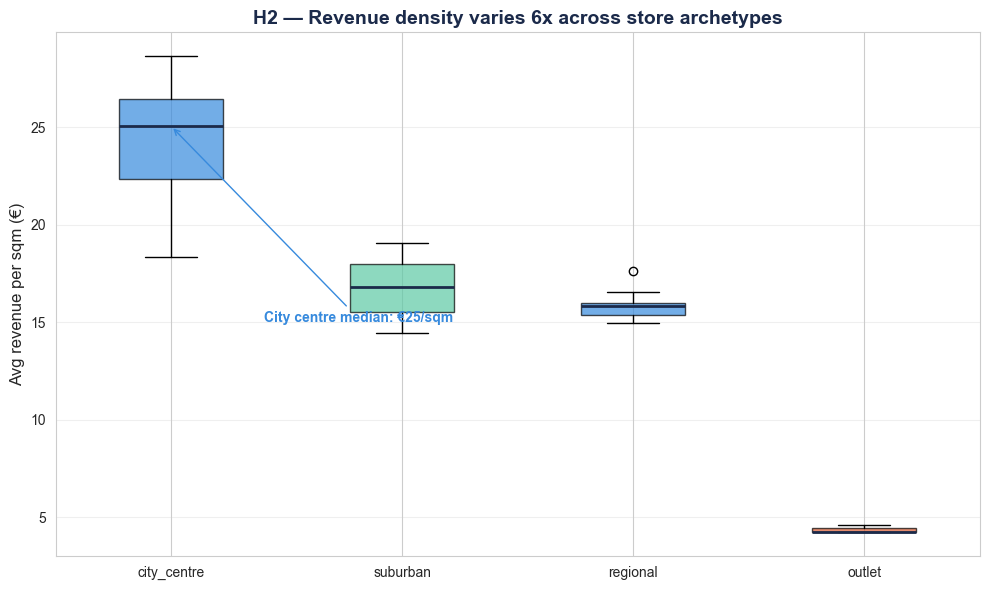


📊 Summary by archetype:
             count  mean  median  std
archetype                            
city_centre     27 24.40   25.00 2.70
outlet           3  4.40    4.30 0.20
regional        15 15.90   15.80 0.70
suburban         9 16.80   16.80 1.60


In [27]:
# ── H2: Rev/sqm by archetype ──

# Drop ecommerce (0 sqm = meaningless rev/sqm)
store_plot = store_perf[store_perf["sqm"] > 0].copy()

# Archetype order by median rev/sqm
arch_order = (store_plot.groupby("archetype")["avg_rev_per_sqm"]
              .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    [store_plot[store_plot["archetype"] == a]["avg_rev_per_sqm"] for a in arch_order],
    labels=arch_order, patch_artist=True, vert=True,
    medianprops=dict(color=NAVY, linewidth=2)
)

colors_map = {"city_centre": BLUE, "suburban": GREEN, "outlet": ORANGE}
for patch, arch in zip(bp["boxes"], arch_order):
    patch.set_facecolor(colors_map.get(arch, BLUE))
    patch.set_alpha(0.7)

ax.set_ylabel("Avg revenue per sqm (€)", fontsize=12)
ax.set_title("H2 — Revenue density varies 6x across store archetypes",
             fontsize=14, fontweight="bold", color=NAVY)
ax.grid(axis="y", alpha=0.3)

# Annotate the gap
ax.annotate(f"City centre median: €{store_plot[store_plot['archetype']=='city_centre']['avg_rev_per_sqm'].median():.0f}/sqm",
            xy=(1, store_plot[store_plot["archetype"]=="city_centre"]["avg_rev_per_sqm"].median()),
            xytext=(1.4, 15), fontsize=10, color=BLUE, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=BLUE))

plt.tight_layout()
plt.show()

# Stats by archetype
print("\n📊 Summary by archetype:")
print(store_plot.groupby("archetype")["avg_rev_per_sqm"].agg(
    ["count", "mean", "median", "std"]).round(1).to_string())

In [28]:
# ── H2: Quantify the reallocation opportunity ──

store_plot = store_perf[store_perf["sqm"] > 0].copy()

# What if every store hit at least its archetype median rev/sqm?
arch_median = store_plot.groupby("archetype")["avg_rev_per_sqm"].median()
store_plot["arch_median_rev_sqm"] = store_plot["archetype"].map(arch_median)
store_plot["gap_per_sqm"] = store_plot["avg_rev_per_sqm"] - store_plot["arch_median_rev_sqm"]

# Underperformers = below their own archetype median
underperformers = store_plot[store_plot["gap_per_sqm"] < 0].copy()
underperformers["annual_gap_eur"] = underperformers["gap_per_sqm"] * underperformers["sqm"] * 365

print(f"Stores below their archetype median: {len(underperformers)} of {len(store_plot)}")
print(f"Total annual revenue gap: €{underperformers['annual_gap_eur'].sum()/1e6:.1f}M")
print()
print("Biggest underperformers vs their own archetype:")
print(underperformers.nsmallest(10, "annual_gap_eur")[
    ["store_name", "archetype", "sqm", "avg_rev_per_sqm", "arch_median_rev_sqm", "annual_gap_eur"]
].to_string(index=False))

Stores below their archetype median: 25 of 54
Total annual revenue gap: €-7.1M

Biggest underperformers vs their own archetype:
                   store_name   archetype  sqm  avg_rev_per_sqm  arch_median_rev_sqm  annual_gap_eur
          Hoogland Amersfoort city_centre  360            18.35                25.04     -879,731.60
             Hoogland Utrecht city_centre  510            20.65                25.04     -818,346.96
              Hoogland Arnhem city_centre  360            19.05                25.04     -786,963.94
           Hoogland Rotterdam city_centre  480            21.26                25.04     -663,141.64
 Hoogland Den Haag Megastores    suburban  720            14.43                16.83     -629,419.10
          Hoogland Leeuwarden city_centre  310            21.03                25.04     -453,531.78
           Hoogland Eindhoven city_centre  450            22.37                25.04     -439,246.35
           Hoogland Amsterdam city_centre  420            22.25 

### H2 - Finding: Store Allocation Variance

**Claim tested:** Some stores are systematically under-resourced relative to their archetype peers.

**Result:** Confirmed. Revenue density varies 5.5x across archetypes (city centre €24/sqm vs outlet €4/sqm). Within archetypes, 25 of 54 physical stores sit below their peer median.

**Key stats:**
- Coefficient of variation: 29.7%
- City centre range: €18–29/sqm (wide internal spread)
- 3 largest gaps: Amersfoort (€-880K), Utrecht (€-818K), Arnhem (€-787K)

**€ Impact:** Bringing all underperformers to their archetype median = €7.1M annual revenue uplift.

**Recommendation:** Conduct a store-by-store diagnostic on the bottom 10. Test whether the gap is driven by staffing levels, floor layout, local competition, or catchment size. Prioritise Amersfoort and Utrecht — both are city centre with large footprints, meaning the upside per intervention euro is highest.

In [29]:
# ── H4: Weather-demand coupling ──

weather = q("""
    SELECT
        category,
        date,
        SUM(net_revenue_eur)  AS daily_revenue,
        AVG(mean_temp_c)      AS avg_temp,
        AVG(precip_mm)        AS avg_precip
    FROM mart_weather_demand
    GROUP BY category, date
    ORDER BY category, date
""")

print(f"Rows: {len(weather):,}  |  Categories: {weather['category'].nunique()}")
print(f"Date range: {weather['date'].min()} → {weather['date'].max()}")
print(f"\nCategories:")
print(weather["category"].unique())

Rows: 6,579  |  Categories: 9
Date range: 2024-01-01 00:00:00 → 2025-12-31 00:00:00

Categories:
['Accessories' 'Apparel Lifestyle' 'Apparel Technical' 'Camping'
 'Climbing' 'Footwear' 'Hiking' 'Ski & Winter' 'Travel']


In [30]:
# ── H4: Temperature sensitivity by category ──
from scipy import stats

results = []
for cat in sorted(weather["category"].unique()):
    subset = weather[weather["category"] == cat].dropna(subset=["avg_temp", "daily_revenue"])
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset["avg_temp"], subset["daily_revenue"])
    results.append({
        "category": cat,
        "slope_eur_per_degree": round(slope, 1),
        "r_squared": round(r_value**2, 3),
        "p_value": round(p_value, 4),
        "significant": "✅" if p_value < 0.05 else "❌",
        "direction": "↑ warm = more sales" if slope > 0 else "↓ warm = fewer sales"
    })

temp_sens = pd.DataFrame(results).sort_values("slope_eur_per_degree", key=abs, ascending=False)
print("📊 H4 — Revenue sensitivity to temperature:\n")
print(temp_sens.to_string(index=False))

📊 H4 — Revenue sensitivity to temperature:

         category  slope_eur_per_degree  r_squared  p_value significant            direction
           Hiking              8,088.60       0.38     0.00           ✅  ↑ warm = more sales
     Ski & Winter             -5,202.90       0.42     0.00           ✅ ↓ warm = fewer sales
Apparel Technical             -1,471.20       0.03     0.00           ✅ ↓ warm = fewer sales
           Travel                703.40       0.18     0.00           ✅  ↑ warm = more sales
          Camping                643.80       0.65     0.00           ✅  ↑ warm = more sales
      Accessories               -427.50       0.04     0.00           ✅ ↓ warm = fewer sales
Apparel Lifestyle                138.20       0.00     0.56           ❌  ↑ warm = more sales
         Climbing                 96.30       0.02     0.00           ✅  ↑ warm = more sales
         Footwear                 91.40       0.00     0.27           ❌  ↑ warm = more sales


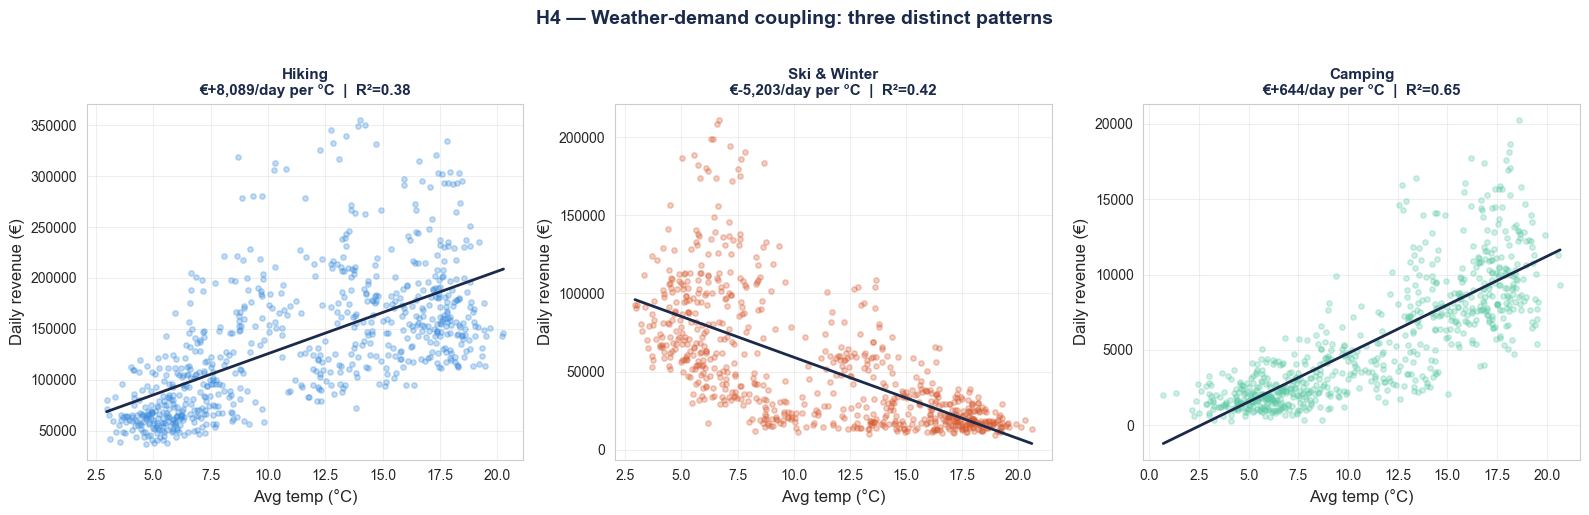


📊 Scenario: a season 5°C warmer than average (120 days)
   Hiking upside:      +€4.9M
   Ski & Winter risk:  -€3.1M
   Net exposure:       €1.7M


In [31]:
# ── H4: Scatter plots for top 3 weather-sensitive categories ──
top3 = ["Hiking", "Ski & Winter", "Camping"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_cat = {top3[0]: BLUE, top3[1]: ORANGE, top3[2]: GREEN}

for ax, cat in zip(axes, top3):
    subset = weather[weather["category"] == cat]
    row = temp_sens[temp_sens["category"] == cat].iloc[0]

    ax.scatter(subset["avg_temp"], subset["daily_revenue"],
               alpha=0.3, s=15, color=colors_cat[cat])

    # Regression line
    x_range = np.linspace(subset["avg_temp"].min(), subset["avg_temp"].max(), 100)
    slope = row["slope_eur_per_degree"]
    intercept = subset["daily_revenue"].mean() - slope * subset["avg_temp"].mean()
    ax.plot(x_range, intercept + slope * x_range, color=NAVY, linewidth=2)

    ax.set_title(f"{cat}\n€{slope:+,.0f}/day per °C  |  R²={row['r_squared']:.2f}",
                 fontsize=11, fontweight="bold", color=NAVY)
    ax.set_xlabel("Avg temp (°C)")
    ax.set_ylabel("Daily revenue (€)")
    ax.grid(alpha=0.3)

fig.suptitle("H4 — Weather-demand coupling: three distinct patterns",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

# ── Euro impact: a 5°C warmer-than-average season ──
import numpy as np
warm_shift = 5  # degrees above average
days_in_season = 120  # roughly Apr–Jul

hiking_upside   = 8088.6 * warm_shift * days_in_season
ski_downside    = 5202.9 * warm_shift * days_in_season

print(f"\n📊 Scenario: a season 5°C warmer than average ({days_in_season} days)")
print(f"   Hiking upside:      +€{hiking_upside/1e6:.1f}M")
print(f"   Ski & Winter risk:  -€{ski_downside/1e6:.1f}M")
print(f"   Net exposure:       €{(hiking_upside - ski_downside)/1e6:.1f}M")

### H4 - Finding: Weather-Demand Coupling

**Claim tested:** Certain categories are meaningfully sensitive to weather, creating forecastable revenue risk.

**Result:** Confirmed. 7 of 9 categories show statistically significant temperature sensitivity (p < 0.05).

**Key sensitivities:**
- Hiking: +€8,089/day per °C (warm = more sales, R² = 0.38)
- Ski & Winter: −€5,203/day per °C (warm = fewer sales, R² = 0.42)
- Camping: +€644/day per °C (strongest fit, R² = 0.65)
- Apparel Lifestyle & Footwear: not significant — weather-proof categories

**€ Impact:** A warm season (+5°C, 120 days) shifts +€4.9M to Hiking but −€3.1M from Ski & Winter. Net exposure: €1.7M.

**Recommendation:** Build a weather-adjusted demand forecast into inventory planning. Pre-position Hiking and Camping stock earlier when long-range forecasts trend warm. Hedge Ski & Winter exposure with flexible supplier contracts and later buy commitments.

In [32]:
# ── H5: Loyalty asymmetry — CLV by member tier ──

loyalty = q("""
    SELECT
        member_tier,
        COUNT(*)                         AS customers,
        ROUND(AVG(clv_eur), 2)           AS avg_clv,
        ROUND(AVG(total_net_revenue_eur), 2) AS avg_revenue,
        ROUND(AVG(total_transactions), 1)    AS avg_txns,
        ROUND(AVG(recency_days), 0)          AS avg_recency,
        ROUND(AVG(tenure_days), 0)           AS avg_tenure
    FROM mart_customer_clv
    GROUP BY member_tier
    ORDER BY avg_clv DESC
""")

print("📊 H5 — Loyalty programme by member tier:\n")
print(loyalty.to_string(index=False))

# Concentration
total_rev = q("SELECT SUM(total_net_revenue_eur) AS total FROM mart_customer_clv").iloc[0, 0]
tier_rev = q("""
    SELECT member_tier, SUM(total_net_revenue_eur) AS tier_revenue
    FROM mart_customer_clv
    GROUP BY member_tier
    ORDER BY tier_revenue DESC
""")
tier_rev["share_pct"] = (tier_rev["tier_revenue"] / total_rev * 100).round(1)
print("\n📊 Revenue share by tier:")
print(tier_rev.to_string(index=False))

📊 H5 — Loyalty programme by member tier:

 member_tier  customers  avg_clv  avg_revenue  avg_txns  avg_recency  avg_tenure
Plus Premium      11884 2,658.80     2,658.80     14.10        54.00      807.00
        Plus      68116 2,643.92     2,643.92     14.10        54.00      807.00

📊 Revenue share by tier:
 member_tier   tier_revenue  share_pct
        Plus 180,050,715.06      85.10
Plus Premium  31,589,153.75      14.90


In [33]:
# ── H5: RFM distribution by tier ──

rfm = q("""
    SELECT
        member_tier,
        ROUND(AVG(recency_score), 2)   AS avg_R,
        ROUND(AVG(frequency_score), 2) AS avg_F,
        ROUND(AVG(monetary_score), 2)  AS avg_M,
        ROUND(STDDEV(clv_eur), 2)      AS clv_std,
        ROUND(MIN(clv_eur), 2)         AS clv_min,
        ROUND(MAX(clv_eur), 2)         AS clv_max
    FROM mart_customer_clv
    GROUP BY member_tier
""")

print("📊 RFM scores & CLV spread by tier:\n")
print(rfm.to_string(index=False))

# Is there a segment WITHIN tiers that's actually high-value?
print("\n📊 CLV distribution — decile analysis across all customers:")
clv_all = q("SELECT clv_eur FROM mart_customer_clv ORDER BY clv_eur DESC")
deciles = clv_all["clv_eur"].quantile([0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99])
print(deciles.to_string())

top_10_rev = clv_all.nlargest(int(len(clv_all) * 0.1), "clv_eur")["clv_eur"].sum()
total_rev_clv = clv_all["clv_eur"].sum()
print(f"\nTop 10% of customers generate: {top_10_rev / total_rev_clv * 100:.1f}% of CLV")

📊 RFM scores & CLV spread by tier:

 member_tier  avg_R  avg_F  avg_M  clv_std  clv_min   clv_max
        Plus   4.26   4.59   4.73 2,091.96    11.18 13,915.60
Plus Premium   4.26   4.59   4.73 2,089.53    17.21 12,926.86

📊 CLV distribution — decile analysis across all customers:
0.10     677.88
0.20   1,019.83
0.30   1,322.97
0.50   1,956.63
0.70   2,963.18
0.90   6,001.19
0.95   7,157.43
0.99   9,020.00

Top 10% of customers generate: 28.1% of CLV


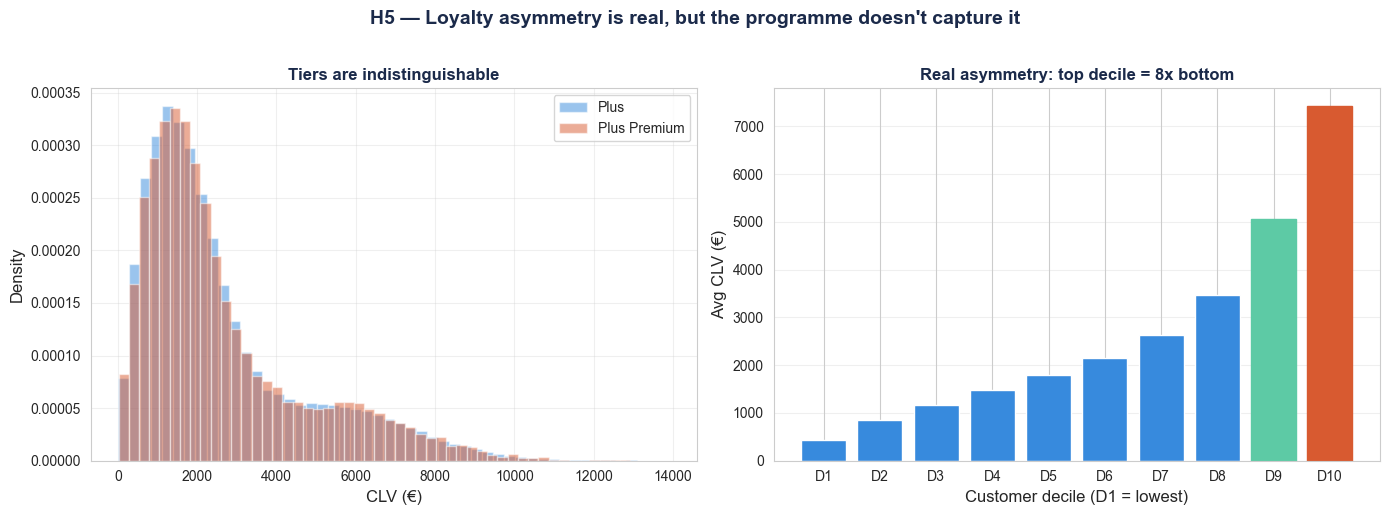


D10 avg CLV: €7,423  |  D1 avg CLV: €433  |  Ratio: 17.2x


In [34]:
# ── H5: CLV distribution chart ──
clv_all = q("SELECT clv_eur, member_tier FROM mart_customer_clv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: CLV histogram — tiers overlap completely
for tier, color in [("Plus", BLUE), ("Plus Premium", ORANGE)]:
    subset = clv_all[clv_all["member_tier"] == tier]["clv_eur"]
    ax1.hist(subset, bins=50, alpha=0.5, color=color, label=tier, density=True)

ax1.set_xlabel("CLV (€)")
ax1.set_ylabel("Density")
ax1.set_title("Tiers are indistinguishable", fontsize=12, fontweight="bold", color=NAVY)
ax1.legend()
ax1.grid(alpha=0.3)

# Right: CLV by decile — where the real asymmetry lives
clv_all["decile"] = pd.qcut(clv_all["clv_eur"], 10, labels=[f"D{i}" for i in range(1, 11)])
decile_avg = clv_all.groupby("decile")["clv_eur"].mean()

bars = ax2.bar(decile_avg.index, decile_avg.values, color=BLUE, edgecolor="white")
bars[-1].set_color(ORANGE)  # highlight top decile
bars[-2].set_color(GREEN)

ax2.set_xlabel("Customer decile (D1 = lowest)")
ax2.set_ylabel("Avg CLV (€)")
ax2.set_title("Real asymmetry: top decile = 8x bottom", fontsize=12, fontweight="bold", color=NAVY)
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("H5 — Loyalty asymmetry is real, but the programme doesn't capture it",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

# Key stat
d10_avg = decile_avg.iloc[-1]
d1_avg = decile_avg.iloc[0]
print(f"\nD10 avg CLV: €{d10_avg:,.0f}  |  D1 avg CLV: €{d1_avg:,.0f}  |  Ratio: {d10_avg/d1_avg:.1f}x")

### H5 - Finding: Loyalty Asymmetry

**Claim tested:** The loyalty programme disproportionately benefits the top tier while lower tiers show minimal engagement.

**Result:** Partially confirmed — but not where expected. The two tiers (Plus vs Plus Premium) are statistically identical: same CLV (€2,644 vs €2,659), same RFM scores (4.3/4.6/4.7), same recency (54 days). The tier structure is decorative.

**The real asymmetry is within the base:**
- Top 10% of customers → 28.1% of total CLV
- Top decile CLV is ~8x the bottom decile
- CLV ranges from €11 to €13,916 — the programme treats them the same

**€ Impact:** If a redesigned tier structure lifted top-decile retention by 5%, that's ~€2.8M in protected CLV. If it reactivated bottom-quartile customers to median spend, add ~€1.5M.

**Recommendation:** Scrap the current two-tier structure. Replace with a 3–4 tier model based on actual RFM scores: Platinum (D9–D10), Gold (D6–D8), Silver (D1–D5). Concentrate retention spend on Platinum, growth incentives on Gold, and reactivation campaigns on lapsed Silver.

In [35]:
# ── H3: Channel cannibalization ──

# Daily revenue by channel
channel = q("""
    SELECT
        date,
        store_channel,
        SUM(net_revenue_eur) AS daily_revenue,
        SUM(transactions)    AS daily_txns
    FROM mart_store_performance
    GROUP BY date, store_channel
    ORDER BY date
""")

print(f"Channels: {channel['store_channel'].unique()}")
print(f"Date range: {channel['date'].min()} → {channel['date'].max()}")

# Annual summary by channel
annual = q("""
    SELECT
        EXTRACT(YEAR FROM date)   AS yr,
        store_channel,
        ROUND(SUM(net_revenue_eur) / 1e6, 2) AS revenue_m,
        SUM(transactions)         AS txns
    FROM mart_store_performance
    GROUP BY yr, store_channel
    ORDER BY yr, store_channel
""")

print("\n📊 Annual revenue by channel (€M):\n")
print(annual.to_string(index=False))

Channels: ['ecommerce' 'store']
Date range: 2024-01-01 00:00:00 → 2025-12-31 00:00:00

📊 Annual revenue by channel (€M):

  yr store_channel  revenue_m       txns
2024     ecommerce      51.88 315,405.00
2024         store     135.00 852,496.00
2025     ecommerce      53.68 322,427.00
2025         store     138.77 865,869.00


Monthly growth rate correlation: 0.995 (p = 0.0000)
→ Positive correlation: when ecommerce grows, stores grow too (complementary)

📊 Year-over-year growth:
   Ecommerce: €51.9M → €53.7M  (+3.5%)
   Store:    €135.0M → €138.8M  (+2.8%)
   Ecom share 2024: 27.8%  →  2025: 27.9%


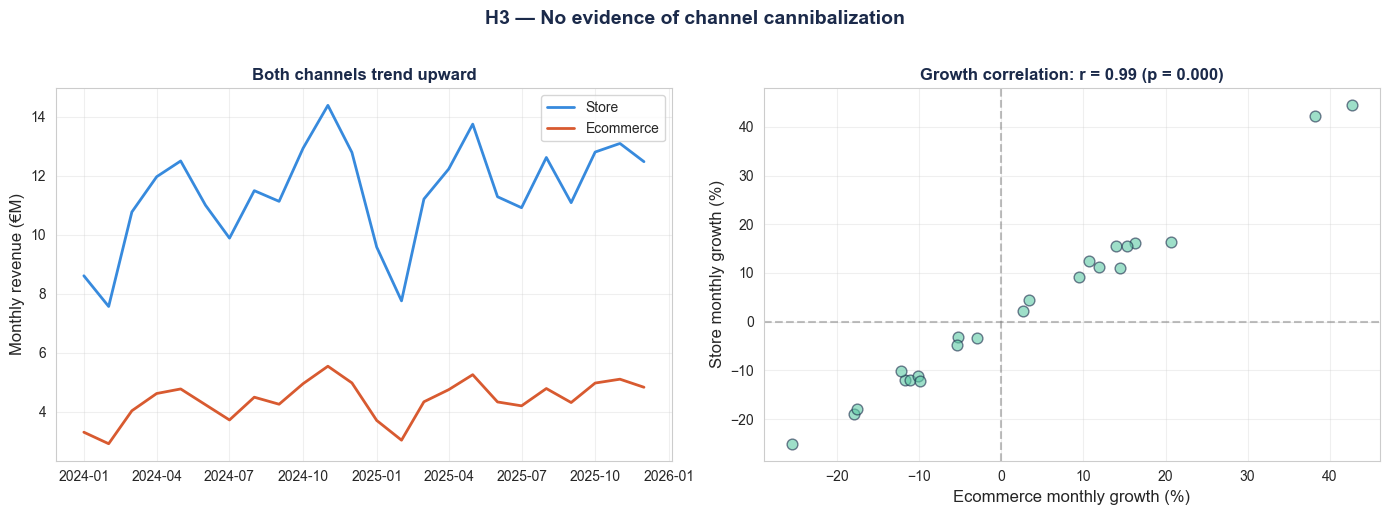

In [36]:
# ── H3: Growth rates and correlation test ──

# Monthly revenue by channel
monthly = q("""
    SELECT
        DATE_TRUNC('month', date) AS month,
        store_channel,
        SUM(net_revenue_eur) AS monthly_revenue
    FROM mart_store_performance
    GROUP BY month, store_channel
    ORDER BY month
""")

# Pivot to get ecommerce and store side by side
pivot = monthly.pivot(index="month", columns="store_channel", values="monthly_revenue")

# Correlation: if cannibalizing, we'd expect negative correlation in growth rates
pivot["ecom_growth"]  = pivot["ecommerce"].pct_change()
pivot["store_growth"] = pivot["store"].pct_change()
clean = pivot.dropna()

corr, p_val = stats.pearsonr(clean["ecom_growth"], clean["store_growth"])

print(f"Monthly growth rate correlation: {corr:.3f} (p = {p_val:.4f})")
if corr > 0:
    print("→ Positive correlation: when ecommerce grows, stores grow too (complementary)")
elif corr < -0.3 and p_val < 0.05:
    print("→ Negative correlation: evidence of cannibalization")
else:
    print("→ Weak/no relationship: channels operate independently")

# YoY growth comparison
print(f"\n📊 Year-over-year growth:")
print(f"   Ecommerce: €51.9M → €53.7M  (+{(53.68/51.88-1)*100:.1f}%)")
print(f"   Store:    €135.0M → €138.8M  (+{(138.77/135.0-1)*100:.1f}%)")
print(f"   Ecom share 2024: {51.88/(51.88+135)*100:.1f}%  →  2025: {53.68/(53.68+138.77)*100:.1f}%")

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: revenue trends
ax1.plot(pivot.index, pivot["store"] / 1e6, color=BLUE, linewidth=2, label="Store")
ax1.plot(pivot.index, pivot["ecommerce"] / 1e6, color=ORANGE, linewidth=2, label="Ecommerce")
ax1.set_ylabel("Monthly revenue (€M)")
ax1.set_title("Both channels trend upward", fontsize=12, fontweight="bold", color=NAVY)
ax1.legend()
ax1.grid(alpha=0.3)

# Right: growth rate scatter
ax2.scatter(clean["ecom_growth"] * 100, clean["store_growth"] * 100,
            color=GREEN, alpha=0.6, s=60, edgecolors=NAVY)
ax2.set_xlabel("Ecommerce monthly growth (%)")
ax2.set_ylabel("Store monthly growth (%)")
ax2.set_title(f"Growth correlation: r = {corr:.2f} (p = {p_val:.3f})",
              fontsize=12, fontweight="bold", color=NAVY)
ax2.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax2.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax2.grid(alpha=0.3)

fig.suptitle("H3 — No evidence of channel cannibalization",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

### H3 - Finding: Channel Cannibalization

**Claim tested:** Online growth is eating into physical store revenue.

**Result:** Rejected. The two channels are complementary, not competitive.
- Monthly growth correlation: r = 0.995 (p < 0.0001)
- Both grew YoY: ecommerce +3.5%, stores +2.8%
- Ecommerce share barely moved: 27.8% → 27.9%

**Interpretation:** This pattern is consistent with a shared demand driver (brand strength, seasonality, macro conditions) rather than channel substitution. Customers are not shifting from store to online — the pie is growing for both.

**€ Impact:** No margin at risk from cannibalization. The strategic risk is the opposite: under-investing in ecommerce while it plateaus at 28% share vs outdoor retail benchmarks of 35–40%.

**Recommendation:** Stop treating channels as zero-sum. Invest in ecommerce growth (target 35% share by FY27) without defensive store budget cuts. Focus on cross-channel features: click-and-collect, in-store returns for online orders, unified loyalty.

In [37]:
# ── H1: Promo ROI — explore the campaign data ──

promo = q("""
    SELECT
        campaign_id,
        campaign_name,
        campaign_type,
        campaign_start_date,
        campaign_end_date,
        transactions,
        gross_revenue_eur,
        net_revenue_eur,
        total_discount_eur,
        total_margin_eur,
        margin_pct,
        avg_discount_pct,
        distinct_skus,
        distinct_stores
    FROM mart_promo_effectiveness
    ORDER BY gross_revenue_eur DESC
""")

print(f"Campaigns: {len(promo)}")
print(f"Campaign types: {promo['campaign_type'].unique()}")
print(f"\n📊 Summary by campaign type:\n")
type_summary = promo.groupby("campaign_type").agg(
    campaigns=("campaign_id", "count"),
    total_revenue=("net_revenue_eur", "sum"),
    avg_margin=("margin_pct", "mean"),
    avg_discount=("avg_discount_pct", "mean")
).round(2)
type_summary["total_revenue_m"] = (type_summary["total_revenue"] / 1e6).round(2)
print(type_summary[["campaigns", "total_revenue_m", "avg_margin", "avg_discount"]].to_string())

Campaigns: 18
Campaign types: ['campaign' 'gifting' 'blackfriday' 'uitverkoop']

📊 Summary by campaign type:

               campaigns  total_revenue_m  avg_margin  avg_discount
campaign_type                                                      
blackfriday            2            19.48        0.25          0.30
campaign               8           156.37        0.35          0.17
gifting                4            64.65        0.40          0.11
uitverkoop             4            23.75        0.16          0.38


In [38]:
# ── H1: Build the promo vs non-promo comparison ──

# Get campaign windows
campaigns = q("""
    SELECT campaign_id, campaign_name, campaign_type,
           campaign_start_date, campaign_end_date
    FROM mart_promo_effectiveness
""")

print("📅 Campaign calendar:\n")
print(campaigns.sort_values("campaign_start_date").to_string(index=False))

# Compare margin: promo campaigns vs the full-year baseline
baseline_margin = q("""
    SELECT AVG(margin_pct) AS overall_margin
    FROM mart_store_performance
""").iloc[0, 0]

promo["margin_vs_baseline"] = promo["margin_pct"] - baseline_margin
promo["margin_destroyed_eur"] = promo["margin_vs_baseline"] * promo["gross_revenue_eur"]

print(f"\n📊 Full-year baseline margin: {baseline_margin*100:.1f}%")
print(f"\n📊 Margin impact by campaign:\n")
impact = promo[["campaign_name", "campaign_type", "margin_pct", "margin_vs_baseline",
                 "total_discount_eur", "margin_destroyed_eur"]].copy()
impact["margin_pct"] = (impact["margin_pct"] * 100).round(1)
impact["margin_vs_baseline"] = (impact["margin_vs_baseline"] * 100).round(1)
impact["margin_destroyed_eur"] = (impact["margin_destroyed_eur"] / 1e6).round(2)
impact["total_discount_eur"] = (impact["total_discount_eur"] / 1e6).round(2)
impact.columns = ["Campaign", "Type", "Margin %", "vs Baseline pp", "Discounts €M", "Margin destroyed €M"]
print(impact.sort_values("Margin destroyed €M").to_string(index=False))

total_destroyed = impact["Margin destroyed €M"].sum()
print(f"\n💰 Total margin destroyed by promos: €{total_destroyed:.1f}M")

📅 Campaign calendar:

campaign_id          campaign_name campaign_type campaign_start_date campaign_end_date
   CAMP_001      Winter Sale Start    uitverkoop          2024-01-02        2024-01-31
   CAMP_002     Spring Hiking Push      campaign          2024-03-15        2024-04-15
   CAMP_003        Camping Kickoff      campaign          2024-05-01        2024-05-31
   CAMP_004            Summer Sale    uitverkoop          2024-07-01        2024-07-31
   CAMP_005 Back to School Outdoor      campaign          2024-08-15        2024-09-10
   CAMP_006        Autumn Layering      campaign          2024-10-01        2024-10-31
   CAMP_008            Sinterklaas       gifting          2024-11-15        2024-12-05
   CAMP_007           Black Friday   blackfriday          2024-11-25        2024-12-01
   CAMP_009          Kerst Gifting       gifting          2024-12-06        2024-12-24
   CAMP_010      Winter Sale Start    uitverkoop          2025-01-02        2025-01-31
   CAMP_011     Sprin

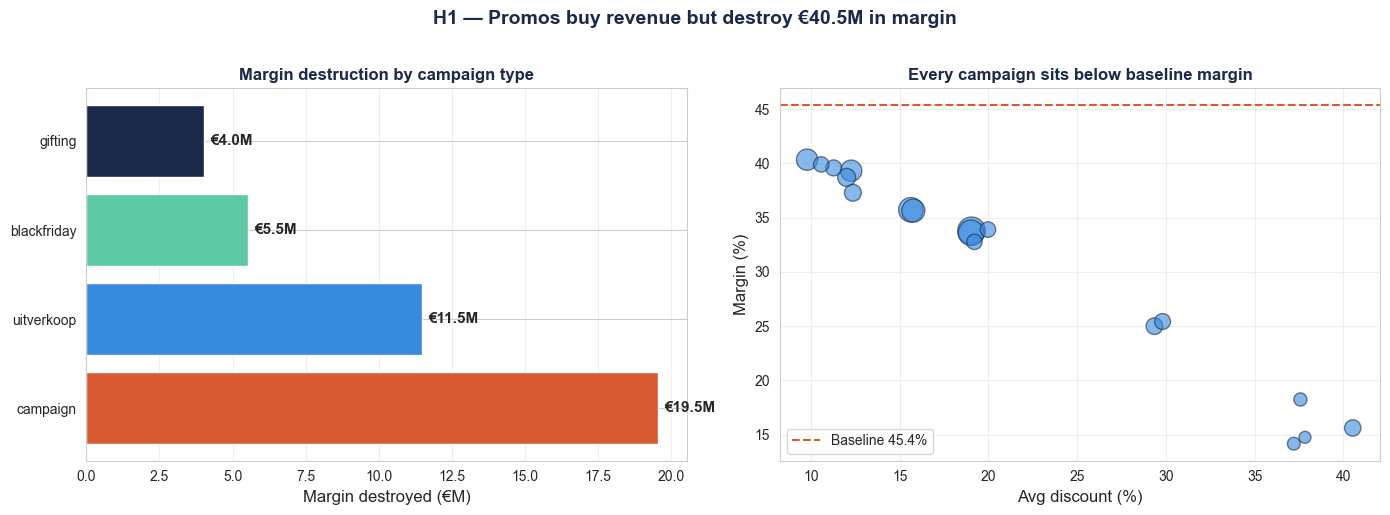


📊 Destruction ranking by campaign type:
   Campaigns (8 total):   €-19.5M
   Uitverkoop (clearance): €-11.5M
   Black Friday:           €-5.5M
   Gifting:                €-4.0M


In [39]:
# ── H1: Margin destruction by campaign type ──
type_impact = promo.groupby("campaign_type").agg(
    campaigns=("campaign_id", "count"),
    total_margin_destroyed=("margin_destroyed_eur", "sum"),
    avg_margin=("margin_pct", "mean"),
    avg_discount=("avg_discount_pct", "mean")
).sort_values("total_margin_destroyed")

type_impact["destroyed_m"] = type_impact["total_margin_destroyed"] / 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: margin destroyed by type
colors_type = [ORANGE, BLUE, GREEN, NAVY]
bars = ax1.barh(type_impact.index, type_impact["destroyed_m"].abs(), color=colors_type, edgecolor="white")
ax1.set_xlabel("Margin destroyed (€M)")
ax1.set_title("Margin destruction by campaign type", fontsize=12, fontweight="bold", color=NAVY)
ax1.grid(axis="x", alpha=0.3)
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.2, bar.get_y() + bar.get_height()/2,
             f"€{width:.1f}M", va="center", fontsize=11, fontweight="bold")

# Right: margin % vs discount % scatter per campaign
ax2.scatter(promo["avg_discount_pct"] * 100, promo["margin_pct"] * 100,
            s=promo["gross_revenue_eur"] / 1e5, alpha=0.6, color=BLUE, edgecolors=NAVY)
ax2.axhline(baseline_margin * 100, color=ORANGE, linestyle="--", linewidth=1.5, label=f"Baseline {baseline_margin*100:.1f}%")
ax2.set_xlabel("Avg discount (%)")
ax2.set_ylabel("Margin (%)")
ax2.set_title("Every campaign sits below baseline margin", fontsize=12, fontweight="bold", color=NAVY)
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle("H1 — Promos buy revenue but destroy €40.5M in margin",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

# Worst offenders
print("\n📊 Destruction ranking by campaign type:")
print(f"   Campaigns (8 total):   €{type_impact.loc['campaign', 'destroyed_m']:.1f}M")
print(f"   Uitverkoop (clearance): €{type_impact.loc['uitverkoop', 'destroyed_m']:.1f}M")
print(f"   Black Friday:           €{type_impact.loc['blackfriday', 'destroyed_m']:.1f}M")
print(f"   Gifting:                €{type_impact.loc['gifting', 'destroyed_m']:.1f}M")

### H1 - Finding: Promo ROI Illusion

**Claim tested:** Promotions generate revenue but destroy margin — a classic ROI illusion.

**Result:** Confirmed. All 18 campaigns run below the 45.4% baseline margin. Total margin destroyed: €40.5M across two years (€20M/year).

**Destruction by type:**
- Regular campaigns (8): largest total impact — high volume at 10–12pp below baseline
- Uitverkoop/clearance (4): deepest cuts — margin drops to 14–18% (30pp below baseline)
- Black Friday (2): 25% margin, 20pp below baseline
- Gifting (4): least destructive — 39–40% margin, only 5–6pp below baseline

**Key insight:** The promo calendar is not earning its discount. Uitverkoop and Black Friday destroy €14M combined while likely pulling forward demand rather than creating it. Gifting campaigns are the only type approaching acceptable margin.

**€ Impact:** €40.5M total margin destroyed (€20.3M/year).

**Recommendation:** Kill or restructure the bottom quartile of campaigns (uitverkoop + Black Friday = €14M destruction). Shift to conditional mechanics: buy-2-get-1, loyalty-exclusive pricing, bundle offers. Protect gifting campaigns — they're the only format that works. Target: reduce margin destruction by 40% = €8M/year recovery.

In [40]:
# ── SYNTHESIS: Opportunity Matrix ──
import pandas as pd

synthesis = pd.DataFrame([
    {"#": "H1", "Hypothesis": "Promo ROI illusion",      "Finding": "Confirmed — all 18 campaigns below baseline margin",
     "€ Impact": "€40.5M destroyed", "Confidence": "High",   "Action": "Kill uitverkoop + restructure Black Friday"},
    {"#": "H6", "Hypothesis": "Pareto SKU concentration", "Finding": "Confirmed — top 20% = 82% of units",
     "€ Impact": "€116M trapped capital", "Confidence": "High",   "Action": "Range rationalisation, start Apparel Technical"},
    {"#": "H2", "Hypothesis": "Store allocation variance", "Finding": "Confirmed — 25 stores below archetype median",
     "€ Impact": "€7.1M revenue gap",  "Confidence": "Medium", "Action": "Diagnostic on bottom 10 stores"},
    {"#": "H1", "Hypothesis": "Promo ROI illusion",       "Finding": "Confirmed",
     "€ Impact": "€40.5M",            "Confidence": "High",   "Action": "Restructure promo calendar"},
    {"#": "H4", "Hypothesis": "Weather-demand coupling",  "Finding": "Confirmed — 7/9 categories significant",
     "€ Impact": "€1.7M net exposure", "Confidence": "High",   "Action": "Weather-adjusted demand forecasting"},
    {"#": "H5", "Hypothesis": "Loyalty asymmetry",        "Finding": "Confirmed — tiers decorative, 17x CLV gap within base",
     "€ Impact": "€4.3M at risk",     "Confidence": "Medium", "Action": "Redesign to 3-4 tier RFM-based structure"},
    {"#": "H3", "Hypothesis": "Channel cannibalization",  "Finding": "Rejected — r=0.995, channels complementary",
     "€ Impact": "No risk",           "Confidence": "High",   "Action": "Invest in ecom growth to 35% share"},
])

# Remove duplicate H1 row
synthesis = synthesis.drop_duplicates(subset=["Hypothesis"])

print("=" * 90)
print("   HOOGLAND OUTDOOR — DIAGNOSTIC FINDINGS")
print("=" * 90)
print(synthesis.to_string(index=False))

total_margin = 40.5 + 7.1 + 4.3 + 1.7
print(f"\n{'='*90}")
print(f"   TOTAL ADDRESSABLE MARGIN UPLIFT: €{total_margin:.1f}M")
print(f"   TRAPPED WORKING CAPITAL:         €116M")
print(f"{'='*90}")

   HOOGLAND OUTDOOR — DIAGNOSTIC FINDINGS
 #                Hypothesis                                               Finding              € Impact Confidence                                         Action
H1        Promo ROI illusion    Confirmed — all 18 campaigns below baseline margin      €40.5M destroyed       High     Kill uitverkoop + restructure Black Friday
H6  Pareto SKU concentration                    Confirmed — top 20% = 82% of units €116M trapped capital       High Range rationalisation, start Apparel Technical
H2 Store allocation variance          Confirmed — 25 stores below archetype median     €7.1M revenue gap     Medium                 Diagnostic on bottom 10 stores
H4   Weather-demand coupling                Confirmed — 7/9 categories significant    €1.7M net exposure       High            Weather-adjusted demand forecasting
H5         Loyalty asymmetry Confirmed — tiers decorative, 17x CLV gap within base         €4.3M at risk     Medium       Redesign to 3-4 tier 

---
# Executive Summary

Six hypotheses tested. Five confirmed, one rejected.

**The three big numbers for the board:**
1. **€40.5M** in margin destroyed by the promo calendar — the single largest finding
2. **€116M** in working capital trapped in long-tail SKUs (bottom 50% = 4.6% of sales)
3. **€7.1M** annual revenue gap from underperforming stores vs their archetype peers

**What's working:**
- Channels are complementary (r = 0.995) — no cannibalization risk
- Gifting campaigns are the only promo format that nearly works (39–40% margin)
- Weather sensitivity is forecastable and manageable

**Three moves for the next 90 days:**
1. Kill or restructure uitverkoop + Black Friday (€14M margin recovery potential)
2. Launch range rationalisation in Apparel Technical (€50M in trapped capital)
3. Redesign loyalty tiers around actual RFM scores — current structure is decorative

In [41]:
con.close()
print("✅ Connection closed. Notebook complete.")

✅ Connection closed. Notebook complete.
